<a href="https://colab.research.google.com/github/ParhamZargar/Machine-Learning/blob/main/Session_04/TehranHouses/Tehran_House_Prices_Tutorial_EN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏠 Python & Machine Learning with Tehran House Prices

For total beginners. We go step by step:

Python basics → load data → look at data → clean → plot → one simple model → better models.

**How to run:** click a grey cell and press `Shift + Enter`. Run cells in order, top to bottom.

Data from [Kaggle](https://www.kaggle.com/datasets/mokar2001/house-price-tehran-iran), saved next to this file as `housePrice.csv`.

---
# Part 1 — Python in a few minutes

Python means giving the computer instructions, one line at a time. Anything after `#` is a note and does not run.

### 1.1 Variables and `print`
A variable is a labelled box that holds a value. `print` shows it.

In [30]:
city = "Tehran"    # text
rooms = 2          # whole number
area = 75.5        # decimal number

print("City:", city)
print("Rooms:", rooms)
print("Area:", area)

City: Tehran
Rooms: 2
Area: 75.5


### 1.2 Math
Python is a strong calculator.

In [2]:
price_per_meter = 50      # million Toman per meter
area = 75.5

print("Rough price:", price_per_meter * area, "million Toman")
print(10 / 4)
print(2 ** 3)             # 2 to the power 3

Rough price: 3775.0 million Toman
2.5
8


### 1.3 List
Several values in a row, inside `[ ]`.

In [3]:
areas = [60, 75, 95, 120]

print(areas)
print(areas[0])     # counting starts at 0
print(areas[-1])    # last item
print(len(areas))   # how many

[60, 75, 95, 120]
60
120
4


### 1.4 Loop
Repeats an action for each item in a list.

In [4]:
for a in [60, 75, 95, 120]:
    print("Apartment of", a, "m2")

Apartment of 60 m2
Apartment of 75 m2
Apartment of 95 m2
Apartment of 120 m2


### 1.5 Function
A ready-made command you write once and call whenever you need it.

In [5]:
def estimate_price(area, price_per_meter):
    return area * price_per_meter

print(estimate_price(75, 50))
print(estimate_price(120, 60))

3750
7200


### 1.6 Libraries
Ready-made tools live in libraries; we `import` them once. These four are the main ones:

- `pandas` (pd): work with data tables
- `numpy` (np): number crunching
- `matplotlib` (plt): draw charts
- `scikit-learn`: machine learning

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

print("Libraries ready ✅")

Libraries ready ✅


---
# Part 2 — Load the data

`pandas` turns a CSV file into a table (a DataFrame). We call this table `df`.

In [31]:
# Direct public URL to the exact same TehranHouse.csv dataset
# Main link to the dataset: https://www.kaggle.com/datasets/valakhorasani/tehran-house-prices-dataset?select=TehranHouse.csv
url = "https://raw.githubusercontent.com/SharifiZarchi/IntroAI/main/Session_04/TehranHouses/housePrice.csv"

# Loads perfectly on local computer, Jupyter, or Google Colab instantly!
df = pd.read_csv(url)

print("Our table has", df.shape[0], "rows and", df.shape[1], "columns")

Our table has 3479 rows and 8 columns


See the first few rows with `.head()`:

In [8]:
df.head()

,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price(USD)
0,63,1,True,True,True,Shahran,1.850000e+09,61666.67
1,60,1,True,True,True,Shahran,1.850000e+09,61666.67
2,79,2,True,True,True,Pardis,5.500000e+08,18333.33
3,95,2,True,True,True,Shahrake Qods,9.025000e+08,30083.33
4,123,2,True,True,True,Shahrake Gharb,7.000000e+09,233333.33


Columns: `Area` size in m², `Room` number of rooms, `Parking`/`Warehouse`/`Elevator` yes-or-no, `Address` neighborhood, `Price` price in Toman, `Price(USD)` price in dollars.

---
# Part 3 — Look at the data

Before any model, get to know the data. Three commands do most of the work: `.info()`, `.describe()`, `.value_counts()`.

### 3.1 `.info()` — column types and missing values

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3479 entries, 0 to 3478
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Area        3479 non-null   object 
 1   Room        3479 non-null   int64  
 2   Parking     3479 non-null   bool   
 3   Warehouse   3479 non-null   bool   
 4   Elevator    3479 non-null   bool   
 5   Address     3456 non-null   object 
 6   Price       3479 non-null   float64
 7   Price(USD)  3479 non-null   float64
dtypes: bool(3), float64(2), int64(1), object(2)
memory usage: 146.2+ KB


Two things stand out: `Address` has fewer values, so some rows have no neighborhood. And `Area` is read as text (object) instead of a number — that's suspicious. We fix it next.

### 3.2 `.describe()` — quick stats for the number columns

In [10]:
df.describe()

,Room,Price,Price(USD)
count,3479.000000,3.479000e+03,3.479000e+03
mean,2.079908,5.359023e+09,1.786341e+05
std,0.758275,8.099935e+09,2.699978e+05
min,0.000000,3.600000e+06,1.200000e+02
25%,2.000000,1.418250e+09,4.727500e+04
50%,2.000000,2.900000e+09,9.666667e+04
75%,2.000000,6.000000e+09,2.000000e+05
max,5.000000,9.240000e+10,3.080000e+06


### 3.3 `.value_counts()` — count categories

In [11]:
print("Apartments by number of rooms:")
print(df["Room"].value_counts())

print("\nMost common neighborhoods:")
print(df["Address"].value_counts().head(10))

Apartments by number of rooms:
Room
2    1961
3     732
1     673
4      70
5      33
0      10
Name: count, dtype: int64

Most common neighborhoods:
Address
Punak                     161
Pardis                    146
West Ferdows Boulevard    145
Gheitarieh                141
Shahran                   130
Saadat Abad               129
Parand                    127
Shahr-e-Ziba              109
Southern Janatabad         93
Central Janatabad          91
Name: count, dtype: int64


---
# Part 4 — Clean the data

Real data is always a bit messy. A model trained on dirty data gives bad answers. Let's fix the two problems.

### 4.1 Turn `Area` into a number
Some `Area` cells have commas or typos, so the whole column became text. We remove commas, then convert to numbers. `errors="coerce"` turns any bad value into `NaN` (meaning missing).

In [12]:
df["Area"] = df["Area"].astype(str).str.replace(",", "", regex=False)
df["Area"] = pd.to_numeric(df["Area"], errors="coerce")

print("Largest Area values:")
print(df["Area"].sort_values(ascending=False).head(8).tolist())

Largest Area values:
[16160000000, 8400000000, 3310000000, 2550000000, 3600, 1000, 929, 900]


### 4.2 Drop impossible apartments (outliers)
A few rows have a huge, clearly wrong area. A normal Tehran apartment is about 30–500 m²; keep only those, and drop rows with missing values. We also add an easier-to-read column: price in billions of Toman.

In [13]:
rows_before = len(df)

df = df[(df["Area"] >= 30) & (df["Area"] <= 500)]
df = df.dropna(subset=["Area", "Price", "Address"])

df["Price_Bn"] = df["Price"] / 1_000_000_000   # billions of Toman

print("Before:", rows_before, " After:", len(df))
df[["Area", "Room", "Price_Bn", "Price(USD)"]].describe()

Before: 3479  After: 3433


,Area,Room,Price_Bn,Price(USD)
count,3433.000000,3433.000000,3433.000000,3.433000e+03
mean,104.018060,2.074279,5.212296,1.737432e+05
std,55.595229,0.748359,7.404752,2.468251e+05
min,30.000000,0.000000,0.003600,1.200000e+02
25%,68.000000,2.000000,1.400000,4.666667e+04
50%,90.000000,2.000000,2.850000,9.500000e+04
75%,120.000000,2.000000,6.000000,2.000000e+05
max,500.000000,5.000000,92.400000,3.080000e+06


From now on we use price in **billions of Toman** (`Price_Bn`) because the numbers are easier to read.

---
# Part 5 — Plots

A picture shows patterns a table hides. We use `matplotlib`. The recipe is always: start chart, draw, add labels, show.

### 5.1 Price histogram
A histogram groups values into bins and shows how many fall in each.

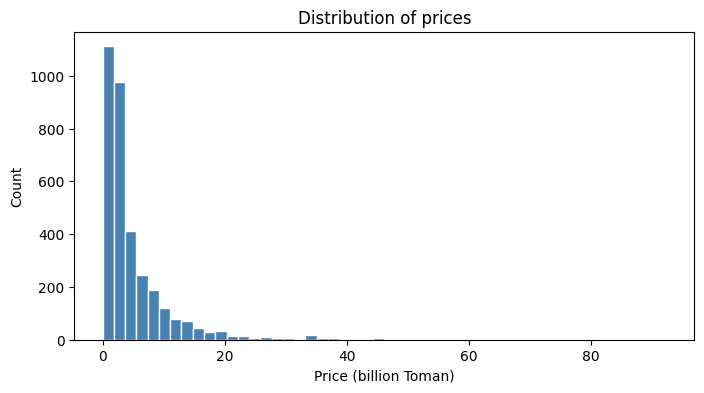

In [14]:
plt.figure(figsize=(8, 4))
plt.hist(df["Price_Bn"], bins=50, color="steelblue", edgecolor="white")
plt.xlabel("Price (billion Toman)")
plt.ylabel("Count")
plt.title("Distribution of prices")
plt.show()

Most homes are cheap, with a long tail of a few very expensive ones. This shape is very common for prices.

### 5.2 Area histogram

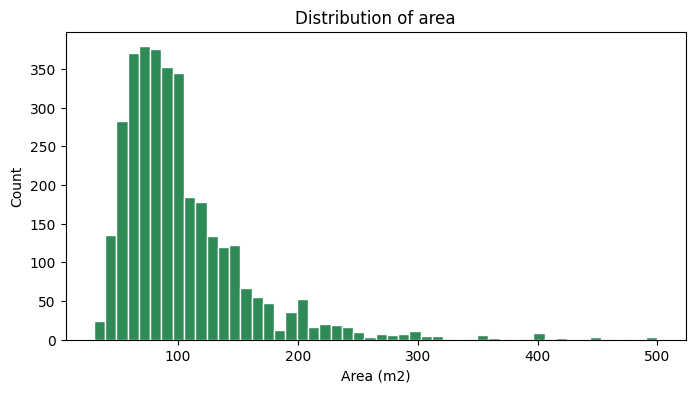

In [15]:
plt.figure(figsize=(8, 4))
plt.hist(df["Area"], bins=50, color="seagreen", edgecolor="white")
plt.xlabel("Area (m2)")
plt.ylabel("Count")
plt.title("Distribution of area")
plt.show()

### 5.3 Scatter plot — does bigger mean pricier?
Each dot is one home: area on the x-axis, price on the y-axis.

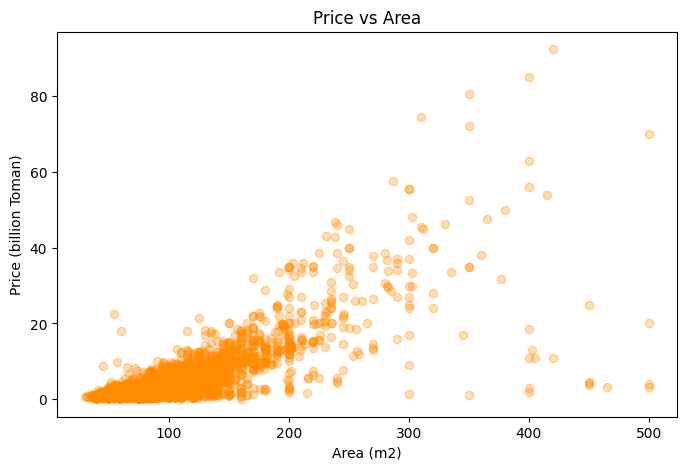

In [16]:
plt.figure(figsize=(8, 5))
plt.scatter(df["Area"], df["Price_Bn"], alpha=0.3, color="darkorange")
plt.xlabel("Area (m2)")
plt.ylabel("Price (billion Toman)")
plt.title("Price vs Area")
plt.show()

The upward trend is clear: bigger homes cost more. Our first model learns exactly this.

### 5.4 Average price by neighborhood

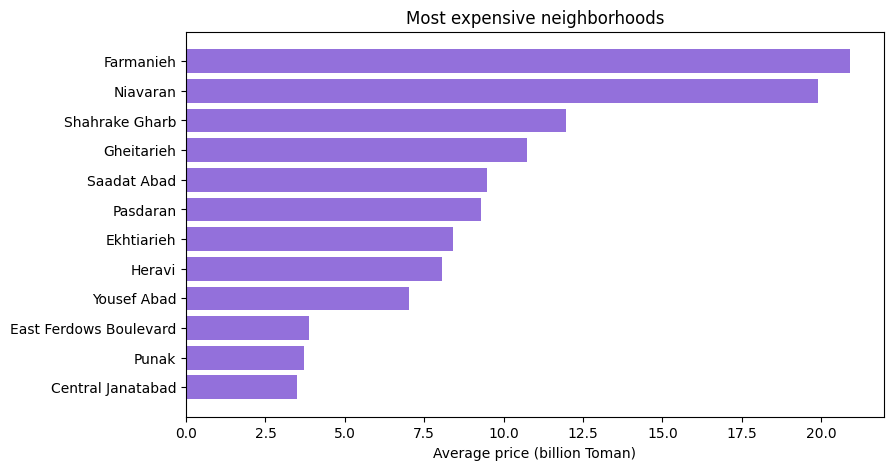

In [17]:
popular = df["Address"].value_counts()
popular = popular[popular >= 30].index
avg_price = (df[df["Address"].isin(popular)]
             .groupby("Address")["Price_Bn"].mean()
             .sort_values(ascending=False)
             .head(12))

plt.figure(figsize=(9, 5))
plt.barh(avg_price.index[::-1], avg_price.values[::-1], color="mediumpurple")
plt.xlabel("Average price (billion Toman)")
plt.title("Most expensive neighborhoods")
plt.show()

### 5.5 Correlation — which numbers move together?
Correlation is a number from -1 to +1. +1 means they rise together, 0 means unrelated.

In [18]:
numeric = df[["Area", "Room", "Parking", "Warehouse", "Elevator", "Price_Bn"]].astype(float)
print(numeric.corr()["Price_Bn"].sort_values(ascending=False))

Price_Bn     1.000000
Area         0.764829
Room         0.573376
Parking      0.208959
Elevator     0.152134
Warehouse    0.124072
Name: Price_Bn, dtype: float64


`Area` has the strongest link with price — that's why we use it for the first model.

---
# Part 6 — Your first machine-learning model

**Goal:** predict price from area.

**Idea (linear regression):** draw the best straight line through the cloud of dots:

$$\text{price} = (\text{slope} \times \text{area}) + \text{intercept}$$

Machine learning just means: let the computer find the best slope and intercept from the data. scikit-learn does it in a few lines.

### 6.1 Prepare the inputs
`X` is the features (inputs), `y` is the target (what we predict).

In [19]:
X = df[["Area"]]      # double [[ ]] keeps it a 2-D table
y = df["Price_Bn"]

print("X:", X.shape, " y:", y.shape)

X: (3433, 1)  y: (3433,)


### 6.2 Split into training and test sets
We train the model on one part and test it on a part it has never seen. This shows if it really learned or just memorized.

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42   # 20% for testing
)

print("Train:", len(X_train), " Test:", len(X_test))

Train: 2746  Test: 687


### 6.3 Train the model
`.fit()` is where the learning happens.

In [21]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print("Slope (price gain per extra m2):", round(model.coef_[0], 4))
print("Intercept:", round(model.intercept_, 4))

Slope (price gain per extra m2): 0.1028
Intercept: -5.4819


So each extra square meter adds about that "slope" amount (in billions of Toman) to the price. A clear result, not a black box.

### 6.4 Show the model's line

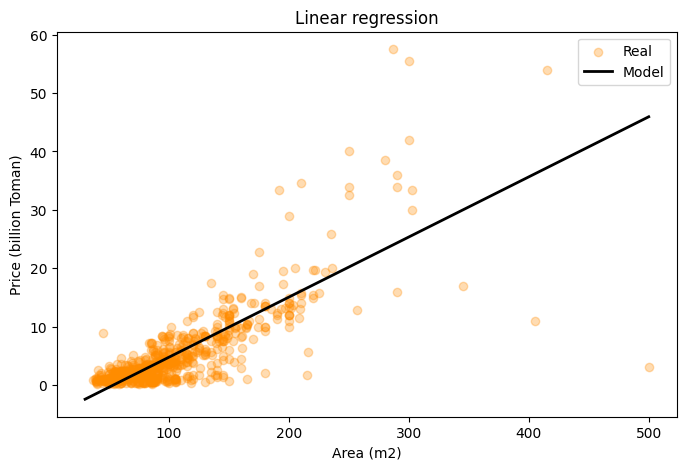

In [22]:
plt.figure(figsize=(8, 5))
plt.scatter(X_test["Area"], y_test, alpha=0.3, color="darkorange", label="Real")

line_x = np.linspace(df["Area"].min(), df["Area"].max(), 100).reshape(-1, 1)
line_x = pd.DataFrame(line_x, columns=["Area"])
plt.plot(line_x["Area"], model.predict(line_x), color="black", linewidth=2, label="Model")

plt.xlabel("Area (m2)")
plt.ylabel("Price (billion Toman)")
plt.title("Linear regression")
plt.legend()
plt.show()

### 6.5 How good is it?
Two common scores: `R²` (share of price changes the model explains; 1 is perfect, 0 is useless) and `MAE` (average error).

In [23]:
from sklearn.metrics import r2_score, mean_absolute_error

predictions = model.predict(X_test)
print("R² :", round(r2_score(y_test, predictions), 3))
print("MAE:", round(mean_absolute_error(y_test, predictions), 3), "billion Toman")

R² : 0.614
MAE: 2.319 billion Toman


### 6.6 A real prediction
What price does the model give for a 100 m² home?

In [24]:
new_apartment = pd.DataFrame({"Area": [100]})
print("Predicted price for 100 m2:", round(model.predict(new_apartment)[0], 2), "billion Toman")

Predicted price for 100 m2: 4.8 billion Toman


---
# Part 7 — Better models: use more information

Area alone is good, but price also depends on rooms, parking, elevator, and most of all the **neighborhood**. Let's give the model everything.

### 7.1 Build a richer feature table
Two steps: turn True/False into 1/0, and turn `Address` (a category, not a number) into many yes/no columns with one-hot encoding (`get_dummies`).

In [25]:
features = df[["Area", "Room", "Parking", "Warehouse", "Elevator", "Address"]].copy()

for col in ["Parking", "Warehouse", "Elevator"]:
    features[col] = features[col].astype(int)

features = pd.get_dummies(features, columns=["Address"], drop_first=True)
print("Now we have", features.shape[1], "feature columns")

X = features
y = df["Price_Bn"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Now we have 195 feature columns


### 7.2 Multi-feature linear regression

In [26]:
multi_model = LinearRegression()
multi_model.fit(X_train, y_train)

predictions = multi_model.predict(X_test)
print("Multi-feature  R²:", round(r2_score(y_test, predictions), 3),
      " MAE:", round(mean_absolute_error(y_test, predictions), 3))

Multi-feature  R²: 0.769  MAE: 1.7


Compare this `R²` with the one-feature model in Part 6 — more information should explain price better.

### 7.3 Ridge and Lasso — "regularized" linear models
With hundreds of neighborhood columns, a plain model can **overfit**: it learns noise in the training data and does worse on new data. Ridge and Lasso add a brake that keeps the numbers small and the model simple. Lasso can even push weak features to zero. The brake strength is set by `alpha`.

One practical tip: these work best when features are on a similar scale, so we first standardize them with `StandardScaler`. A `Pipeline` chains the two steps together.

In [27]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

for name, regressor in [("Ridge", Ridge(alpha=1.0)),
                        ("Lasso", Lasso(alpha=0.01))]:
    pipe = make_pipeline(StandardScaler(), regressor)
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    print(f"{name:6s} R²: {r2_score(y_test, pred):.3f}  MAE: {mean_absolute_error(y_test, pred):.3f}")

Ridge  R²: 0.769  MAE: 1.699
Lasso  R²: 0.770  MAE: 1.678


### 7.4 Which features matter most?
The model's numbers (coefficients) show how much each feature pushes price up or down.

In [28]:
coefficients = pd.Series(multi_model.coef_, index=X.columns)

print("Biggest positive effect on price:")
print(coefficients.sort_values(ascending=False).head(10))

print("\nBiggest negative effect on price:")
print(coefficients.sort_values().head(10))

Biggest positive effect on price:
Address_Gandhi        31.198411
Address_Lavasan       21.187553
Address_Elahieh       11.619306
Address_Zaferanieh    10.783904
Address_Velenjak      10.208362
Address_Niavaran       8.618147
Address_Farmanieh      8.337040
Address_Aqdasieh       6.909282
Address_Kamranieh      5.603984
Address_Ajudaniye      5.342506
dtype: float64

Biggest negative effect on price:
Address_Absard              -34.022350
Address_Chardangeh           -9.273862
Address_Shahedshahr          -8.611000
Address_Damavand             -8.377948
Address_Salehabad            -6.130240
Address_Khademabad Garden    -6.121763
Address_Pakdasht             -5.728629
Address_Southern Chitgar     -5.480127
Address_Majidieh             -5.358358
Address_Argentina            -5.345906
dtype: float64


The neighborhoods with the biggest positive numbers are the expensive parts of Tehran. From data alone, the model found what every local knows: **location drives price.**

---
# Wrap-up

In this notebook: Python basics, loading data, getting to know it, cleaning, plots, a one-feature model, then multi-feature and Ridge/Lasso models.

To practice: predict the dollar price (`Price(USD)`); try a non-linear model like `RandomForestRegressor`; change `alpha` and watch the scores move.

The same path — load, explore, clean, plot, model, evaluate — works for almost any other dataset too. Done! 🎉